# Scratch paper for full model usage issues 

In [1]:
from sklearn.inspection import PartialDependenceDisplay
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR 
import importlib
import sys 
# from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
from xgboost import XGBClassifier
import seaborn as sns
import matplotlib.pyplot as plt 
import pandas as pd

sys.path.append("../")

from proj_mod import visualization, data_processing, training 
importlib.reload(visualization);
importlib.reload(data_processing);
importlib.reload(training); 

seed=420 

## Attempt to see if there is any relationship I can get between the prob predict of the full and the personal model - hoping for some non-strictly increasing relationships 

In [2]:
full_model=training.model_eval(search_method="Random")

In [ ]:
per_model=training.model_eval(search_method="Random")

In [4]:
full_model.load_dict(load_path="../data/fitted/xgboost/compressed_fitted_dict_xgboost_RFEtune_run1.gz", compress=True)

Loading completed. 


In [5]:
per_model.load_dict(load_path="../data/fitted/xgboost/fitted_dict_per_noRFE_run1.pkl")

Loading completed. 


In [8]:
full_model.fitted_dict_explain()

The dictionary has key being the fold identifier, and a tuple value for each key. The indexes of the tuple, ordered by from 0 to 4, are:
 * The best pipeline for this fold
 * The f1 score of the best pipeline in this fold
 * The roc auc of the best pipeline in this fold
 * The average precision of the best pipeline in this fold
  * The pred_proba produced by the pipeline in this fold.



In [11]:
fp1=full_model.fitted_dict_["Fold 1"][4]
pp1=per_model.fitted_dict_["Fold 1"][4]

In [14]:
fp=np.concatenate((
    full_model.fitted_dict_["Fold 1"][4],
    full_model.fitted_dict_["Fold 2"][4], 
    full_model.fitted_dict_["Fold 3"][4], 
    full_model.fitted_dict_["Fold 4"][4], 
    full_model.fitted_dict_["Fold 5"][4]
))
pp=np.concatenate((
    per_model.fitted_dict_["Fold 1"][4], 
    per_model.fitted_dict_["Fold 2"][4], 
    per_model.fitted_dict_["Fold 3"][4], 
    per_model.fitted_dict_["Fold 4"][4], 
    per_model.fitted_dict_["Fold 5"][4]
))

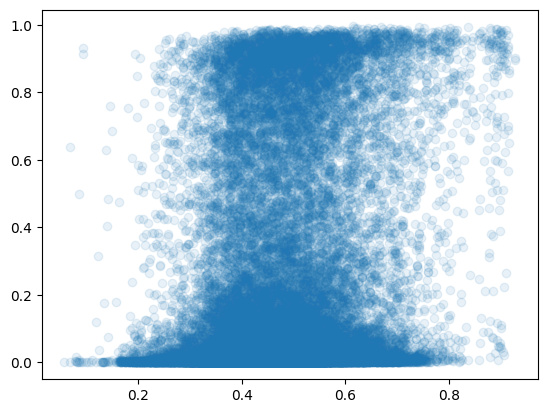

In [69]:
plt.scatter(pp, fp, alpha=0.1)
plt.show()

Intuitively, it seems that the variance increased and then reduced again along the increment of personal model proba prediction, but no clear trend visually other than a seemingly positive linear relationship. 

In [24]:
pp[..., None]

array([[0.35197115],
       [0.4648715 ],
       [0.46919116],
       ...,
       [0.596254  ],
       [0.64496475],
       [0.5029701 ]], dtype=float32)

In [25]:
fp

array([0.00256402, 0.00538468, 0.06454116, ..., 0.8660452 , 0.79985964,
       0.8390183 ], dtype=float32)

In [66]:
ols=LinearRegression()
ols.fit(X=pp[...,None], y=fp)
ols_out=ols.predict(X=pp[...,None])

In [67]:
svr=SVR(kernel='rbf',C=100, epsilon=0.1)
svr.fit(X=pp[...,None], y=fp)
svr_out=svr.predict(X=pp[...,None])

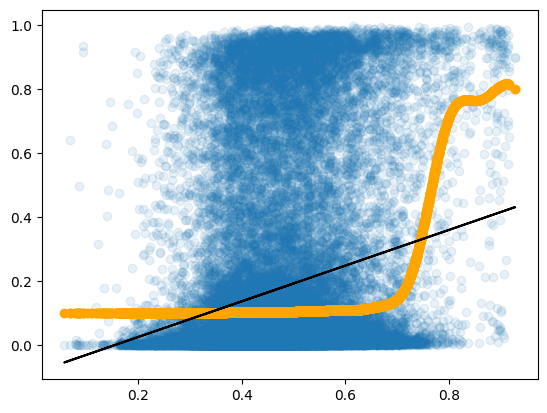

In [68]:
plt.scatter(pp, fp, alpha=0.1)
plt.plot(pp, ols_out, c="black")
plt.scatter(pp, svr_out, c="orange")
plt.show()

Not helpful, it seems that most of the signal is, indeed, within the "campaign" features. But the shape looked a little "sigmoid", let's reverse that and try again. 

In [56]:
sifp=-np.log(1/fp -1)

In [57]:
ols=LinearRegression()
ols.fit(X=pp[...,None], y=sifp)
ols_out=ols.predict(X=pp[...,None])

In [58]:
svr=SVR(kernel='rbf',C=100, epsilon=0.1)
svr.fit(X=pp[...,None], y=sifp)
svr_out=svr.predict(X=pp[...,None])

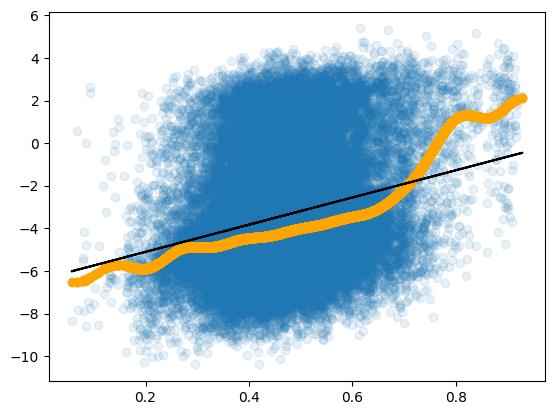

In [65]:
plt.scatter(x=pp, y=sifp, alpha=0.1)
plt.plot(pp, ols_out, c="black")
plt.scatter(pp, svr_out, c="orange")
plt.show()

In [60]:
ols_sig=1/(1+np.exp(-ols_out))
svr_sig=1/(1+np.exp(-svr_out))

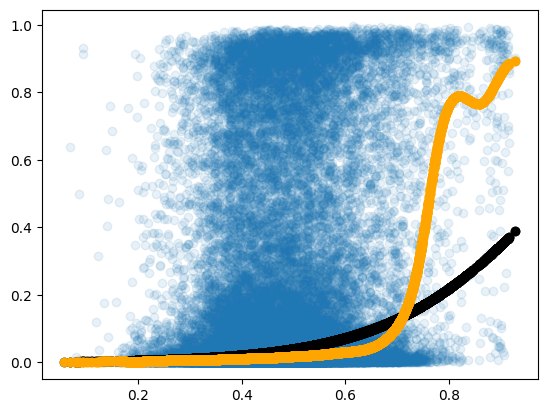

In [64]:
plt.scatter(x=pp, y=fp, alpha=0.1)
plt.scatter(pp, ols_sig, c="black")
plt.scatter(pp, svr_sig, c="orange")
plt.show()

The linear one (black) is just for intuition, the svr (orange) is supposed to be more "flexible", but it is still (mostly) never decreasing - expect for a very short interval around $0.8$, all it will (mostly) do is "move, squeeze, or strech" the threshold metric curve(s), the trade off is not (in large) impacted. 

I think it can be said now that most impact is within the "campaign" features. 

## Playing around with PDP and ICE 

In [5]:
df=pd.read_csv("../data/raw.csv")
df["y"]=df["y"].map({"no": 0, "yes": 1})
features=df.columns[:-1]
df_feat=df[features]
# df_feat["month_num"]=df_feat["month"].map({"jan":1, "feb":2, "mar":3, "apr":4, "may":5, "jun":6, "jul":7, "aug":8, "sep":9, "oct":10, "nov":11, "dec":12}).to_numpy().astype(int)
# df_feat["day_of_year"]=data_processing.day_of_non_leap_np(month_arr=df_feat["month_num"].to_numpy(), day_arr=df_feat["day"].to_numpy()).astype(int)
df_tar=df[["y"]]

In [6]:
SKF=StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
outer_split=list(SKF.split(X=df_feat, y=df_tar))

In [7]:
X_1_train=df_feat.iloc[outer_split[0][0]]

In [6]:
df_feat.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign'],
      dtype='object')

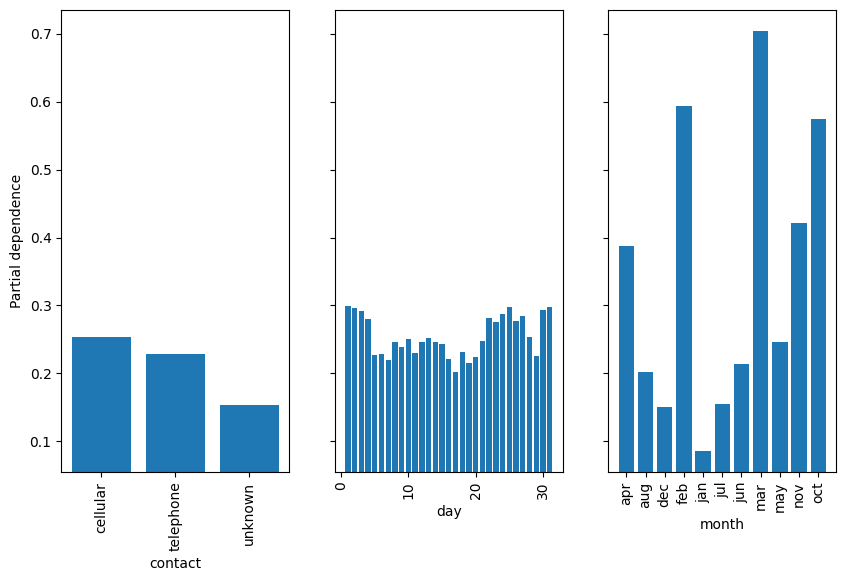

In [14]:
features_to_plot_cate=['contact', 'day', 'month']
fig,ax=plt.subplots(figsize=(10,6))
display=PartialDependenceDisplay.from_estimator(
    estimator=full_model.fitted_dict_["Fold 1"][0], 
    X=X_1_train, 
    features=features_to_plot_cate, 
    feature_names=X_1_train.columns.tolist(), 
    categorical_features=['contact', 'day', 'month'],
    target=1, 
    kind="average",
    ax=ax, 
    ice_lines_kw={"color": "orange", "alpha": 0.4}, 
    pd_line_kw={"color": "blue", "linestyle": "--"}
)
plt.show()

/home/ycoeusz/.pyenv/versions/deep_learning_3_11_8/lib/python3.11/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning: The column 11 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
/home/ycoeusz/.pyenv/versions/deep_learning_3_11_8/lib/python3.11/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning: The column 12 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


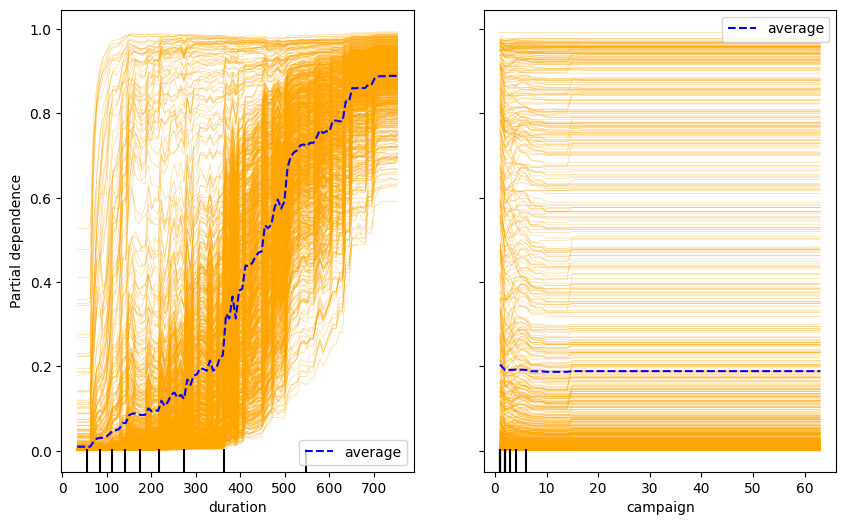

In [16]:
features_to_plot=['duration', 'campaign']
fig,ax=plt.subplots(figsize=(10,6))
display=PartialDependenceDisplay.from_estimator(
    estimator=full_model.fitted_dict_["Fold 1"][0], 
    X=X_1_train, 
    features=features_to_plot, 
    feature_names=X_1_train.columns.tolist(), 
    target=1, 
    kind="both",
    ax=ax, 
    ice_lines_kw={"color": "orange", "alpha": 0.4}, 
    pd_line_kw={"color": "blue", "linestyle": "--"}
)
plt.show()

In [14]:
df_feat_num=df_feat.copy(deep=True)
df_feat_num["contact"]=df_feat_num["contact"].map({'unknown': 0, 'cellular':2, 'telephone':1}).astype(int)
df_feat_num["month_num"]=df_feat_num["month"].map({"jan":1, "feb":2, "mar":3, "apr":4, "may":5, "jun":6, "jul":7, "aug":8, "sep":9, "oct":10, "nov":11, "dec":12}).to_numpy().astype(int)
df_feat_num["day_of_year"]=data_processing.day_of_non_leap_np(month_arr=df_feat_num["month_num"].to_numpy(), day_arr=df_feat_num["day"].to_numpy()).astype(int)
df_feat_num.drop(columns=["day", "month", "month_num"], inplace=True)
df_feat_num

,age,job,marital,education,default,balance,housing,loan,contact,duration,campaign,day_of_year
0,58,management,married,tertiary,no,2143,yes,no,0,261,1,125
1,44,technician,single,secondary,no,29,yes,no,0,151,1,125
2,33,entrepreneur,married,secondary,no,2,yes,yes,0,76,1,125
3,47,blue-collar,married,unknown,no,1506,yes,no,0,92,1,125
4,33,unknown,single,unknown,no,1,no,no,0,198,1,125
...,...,...,...,...,...,...,...,...,...,...,...,...
39995,53,technician,married,tertiary,no,395,no,no,2,107,1,154
39996,30,management,single,tertiary,no,3340,no,no,2,238,3,154
39997,54,admin,divorced,secondary,no,200,no,no,2,170,1,154
39998,34,management,married,tertiary,no,1047,no,no,2,342,1,154


In [15]:
df_feat

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,53,technician,married,tertiary,no,395,no,no,cellular,3,jun,107,1
39996,30,management,single,tertiary,no,3340,no,no,cellular,3,jun,238,3
39997,54,admin,divorced,secondary,no,200,no,no,cellular,3,jun,170,1
39998,34,management,married,tertiary,no,1047,no,no,cellular,3,jun,342,1


In [52]:
def get_md(day_of_year: np.ndarray): 
    base_date=np.datetime64("1990-01-01", "D")
    target_dates=base_date + np.timedelta64(1, "D") * (day_of_year-1)
    
    dates=pd.Series(target_dates)
    months=dates.dt.month.to_numpy()
    days=dates.dt.day.to_numpy()
    
    return months, days 

In [53]:
get_md(df_feat_num["day_of_year"].to_numpy())

(array([5, 5, 5, ..., 6, 6, 6], dtype=int32),
 array([5, 5, 5, ..., 3, 3, 3], dtype=int32))

In [56]:
from sklearn.base import BaseEstimator, TransformerMixin

class back_transform(BaseEstimator, TransformerMixin): 
    def __init__(self):
        pass 
    def fit(self): 
        pass 
    def transform(self, X: pd.DataFrame): 
        out=X.copy(deep=True)
        
        out["contact"]=out["contact"].map({0:'unknown', 2:'cellular', 1:'telephone'}).astype(str)
        months, days = get_md(out["day_of_year"].to_numpy())
        month_dict={1:"jan", 2:"feb", 3:"mar", 4:"apr", 5:"may", 6:"jun", 7:"jul", 8:"aug", 9:"sep", 10:"oct", 11:"nov", 12:"dec"}
        map_func=np.vectorize(lambda x: month_dict[x])
        months=map_func(months).astype(str)
        out["day"]=days.astype(int) 
        out["month"]=months.astype(str) 
        out.drop(columns=["day_of_year"], inplace=True)
        
        return out 

In [57]:
bt=back_transform()
df_feat_back=bt.transform(df_feat_num)
df_feat_back

,age,job,marital,education,default,balance,housing,loan,contact,duration,campaign,day,month
0,58,management,married,tertiary,no,2143,yes,no,unknown,261,1,5,may
1,44,technician,single,secondary,no,29,yes,no,unknown,151,1,5,may
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,76,1,5,may
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,92,1,5,may
4,33,unknown,single,unknown,no,1,no,no,unknown,198,1,5,may
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,53,technician,married,tertiary,no,395,no,no,cellular,107,1,3,jun
39996,30,management,single,tertiary,no,3340,no,no,cellular,238,3,3,jun
39997,54,admin,divorced,secondary,no,200,no,no,cellular,170,1,3,jun
39998,34,management,married,tertiary,no,1047,no,no,cellular,342,1,3,jun


In [58]:
X_1_num_train=df_feat_num.iloc[outer_split[0][0]]
X_1_num_train

,age,job,marital,education,default,balance,housing,loan,contact,duration,campaign,day_of_year
0,58,management,married,tertiary,no,2143,yes,no,0,261,1,125
2,33,entrepreneur,married,secondary,no,2,yes,yes,0,76,1,125
3,47,blue-collar,married,unknown,no,1506,yes,no,0,92,1,125
5,35,management,married,tertiary,no,231,yes,no,0,139,1,125
6,28,management,single,tertiary,no,447,yes,yes,0,217,1,125
...,...,...,...,...,...,...,...,...,...,...,...,...
39994,35,management,married,tertiary,no,3109,yes,no,2,467,1,154
39996,30,management,single,tertiary,no,3340,no,no,2,238,3,154
39997,54,admin,divorced,secondary,no,200,no,no,2,170,1,154
39998,34,management,married,tertiary,no,1047,no,no,2,342,1,154


In [59]:
X_1_num_train["day_of_year"].isna().any()

np.False_

In [61]:
bt=back_transform()
X_1_num_train_back=bt.transform(X_1_num_train)
X_1_num_train_back["month"].isna().any()

np.False_

In [62]:
from sklearn.pipeline import Pipeline

pipe1=Pipeline([("bt", back_transform()), ("est", full_model.fitted_dict_["Fold 1"][0])])

In [64]:
pipe1.predict_proba(X_1_num_train)

array([[9.7690600e-01, 2.3094008e-02],
       [9.9932283e-01, 6.7716325e-04],
       [9.9905592e-01, 9.4407744e-04],
       ...,
       [1.9473040e-01, 8.0526960e-01],
       [5.3612232e-02, 9.4638777e-01],
       [7.3598039e-01, 2.6401964e-01]], dtype=float32)

In [65]:
X_1_num_train.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'duration', 'campaign', 'day_of_year'],
      dtype='object')

/home/ycoeusz/.pyenv/versions/deep_learning_3_11_8/lib/python3.11/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning: The column 8 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
/home/ycoeusz/.pyenv/versions/deep_learning_3_11_8/lib/python3.11/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning: The column 9 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
/home/ycoeusz/.pye

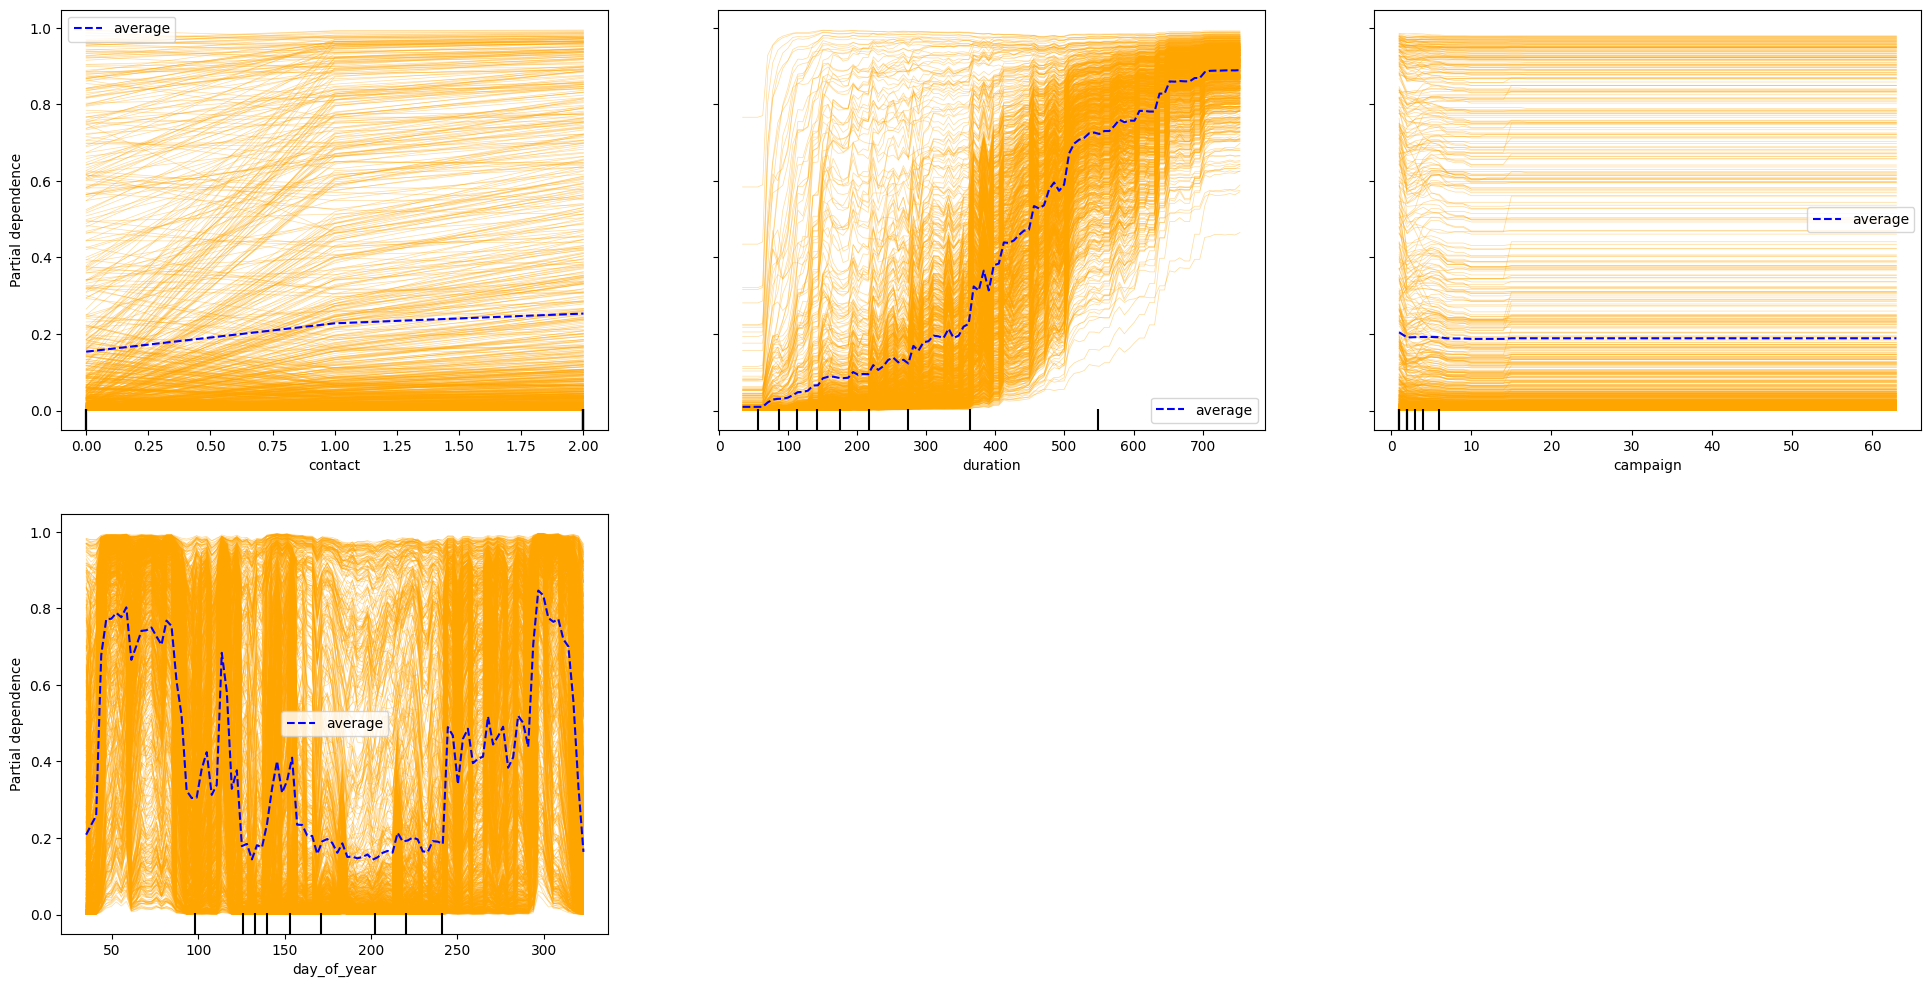

In [70]:
pipe1=Pipeline([("bt", back_transform()), ("est", full_model.fitted_dict_["Fold 1"][0])])
features_to_plot=['contact', 'duration', 'campaign', 'day_of_year']
fig,ax=plt.subplots(figsize=(24,12))
display=PartialDependenceDisplay.from_estimator(
    estimator=pipe1, 
    X=X_1_num_train, 
    features=features_to_plot, 
    feature_names=X_1_num_train.columns.tolist(), 
    target=1, 
    kind="both",
    ax=ax, 
    ice_lines_kw={"color": "orange", "alpha": 0.4}, 
    pd_line_kw={"color": "blue", "linestyle": "--"}
)
plt.show()

## **New Plan 1**: Instead of focusing on the personal model, we utilize the full model but reset the "campaign (count)" feature to $1$, and rank the customers $\propto \frac{\text{highest ``potential''}}{\text{``duration'' need for the target potential}}$ with a preset target "potential" and a limit of "duration" under which restriction we will calculate the highest "potential", in case a customer never reaches target "potential" under the "duration" restriction, we will set the score to $0$ in ranking; or $\propto \text{area under the ice curve of feature ``duration''}$ (Or something alike, the essence is to promote early high potential, but also max ``potential''). 
## **New Plan 2**: Extending on New plan 1 above, we allow for overriding "campaign (count)" feature to any $m\geq 1$ (within reason). The previous reach outs are simply "sunken cost". 
## **New Plan 3**: Update the metric by threshold trade to be conditional on "campaign (count)" number, this should help with determine the precision and FNR for each campaign round with a predetermined target ``potential'' set by the user. 
## **Remark**: The ``Potential'' here is not calibrated, it does not represent accurate probability. 

## Created a new layer so that I can change "day of year" to and "day" "month", and numerical values for "contact" to categorical contact as well. I can keep using the trained model and detect individual changes for these features as well in this way - sklearn pdp can not do individual for categorical features. 

* ## We can see that, although day of year, on average, seem to favor end and beginning of the year, there are customers we can "work on" in the middle as well, so our ranker should be done with day of year in mind. 

* ## For contact, method, it turns out "2 <-> cellular" is preferable in general, we will not focus on this in our ranker - we will set the default to be cellular. 

## **New idea**: Potential value of the customer should not be only about the max proba one could get by reaching out to the customer, but also about how little effort ("duration" feature) is needed to do so. 